In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

# Sinh dữ liệu
N = 150
u0 = np.random.rand(N)
r0 = np.sqrt(u0)
theta0 = np.random.rand(N) * 2 * np.pi
X0 = np.c_[r0 * np.cos(theta0), r0 * np.sin(theta0)]
y0 = np.zeros(N)

u1 = np.random.rand(N)
r1 = np.sqrt(4 * u1 + 2.25)
theta1 = np.random.rand(N) * 2 * np.pi
X1 = np.c_[r1 * np.cos(theta1), r1 * np.sin(theta1)]
y1 = np.ones(N)

X = np.vstack((X0, X1))
y = np.hstack((y0, y1))

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = torch.FloatTensor(X_train_np)
y_train = torch.FloatTensor(y_train_np).unsqueeze(1)
X_test  = torch.FloatTensor(X_test_np)
y_test  = torch.FloatTensor(y_test_np).unsqueeze(1)

Test Acc (4 nodes): 98.33% | Final Loss: 0.0364
Test Acc (8 nodes): 100.00% | Final Loss: 0.0065
Test Acc (8+6 nodes): 100.00% | Final Loss: 0.0004


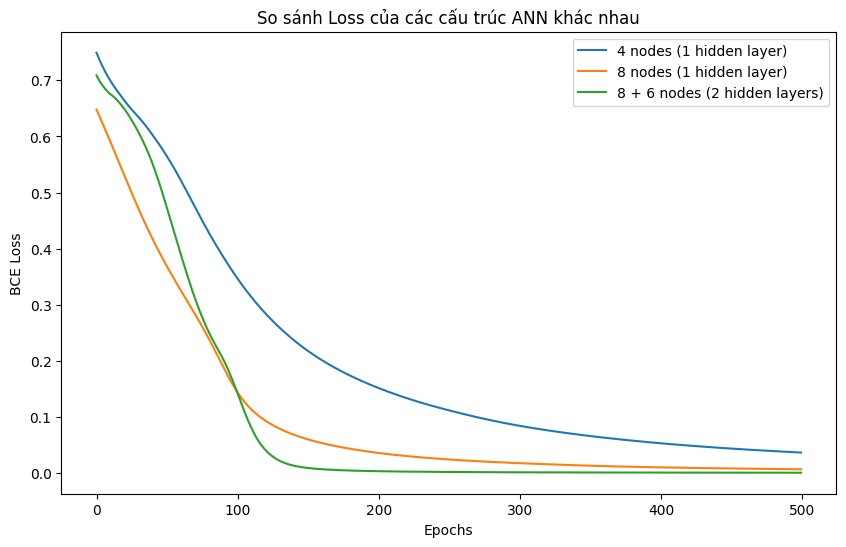

In [2]:
# 1. Định nghĩa các hàm và mô hình
def train_model(model, epochs=500, lr=0.01):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

    model.eval()
    with torch.no_grad():
        pred = (model(X_test) > 0.5).float()
        acc = (pred == y_test).float().mean().item()
    return loss_history, acc

# Kiến trúc 1: 4 nút ẩn (Mô hình gốc)
class ANN_4(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 4), nn.ReLU(), nn.Linear(4, 1), nn.Sigmoid())
    def forward(self, x): return self.net(x)

# Kiến trúc 2: 8 nút ẩn
class ANN_8(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
    def forward(self, x): return self.net(x)

# Kiến trúc 3: 8 nút + 6 nút
class ANN_8_6(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8), nn.ReLU(),
            nn.Linear(8, 6), nn.ReLU(),
            nn.Linear(6, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

# 2. Huấn luyện và lấy kết quả
loss_4, acc_4 = train_model(ANN_4())
loss_8, acc_8 = train_model(ANN_8())
loss_8_6, acc_8_6 = train_model(ANN_8_6())

print(f"Test Acc (4 nodes): {acc_4*100:.2f}% | Final Loss: {loss_4[-1]:.4f}")
print(f"Test Acc (8 nodes): {acc_8*100:.2f}% | Final Loss: {loss_8[-1]:.4f}")
print(f"Test Acc (8+6 nodes): {acc_8_6*100:.2f}% | Final Loss: {loss_8_6[-1]:.4f}")

# 3. Vẽ đồ thị so sánh
plt.figure(figsize=(10, 6))
plt.plot(loss_4, label='4 nodes (1 hidden layer)')
plt.plot(loss_8, label='8 nodes (1 hidden layer)')
plt.plot(loss_8_6, label='8 + 6 nodes (2 hidden layers)')
plt.xlabel('Epochs')
plt.ylabel('BCE Loss')
plt.title('So sánh Loss của các cấu trúc ANN khác nhau')
plt.legend()
plt.show()

BCEWithLogitsLoss - Test Acc: 100.00%


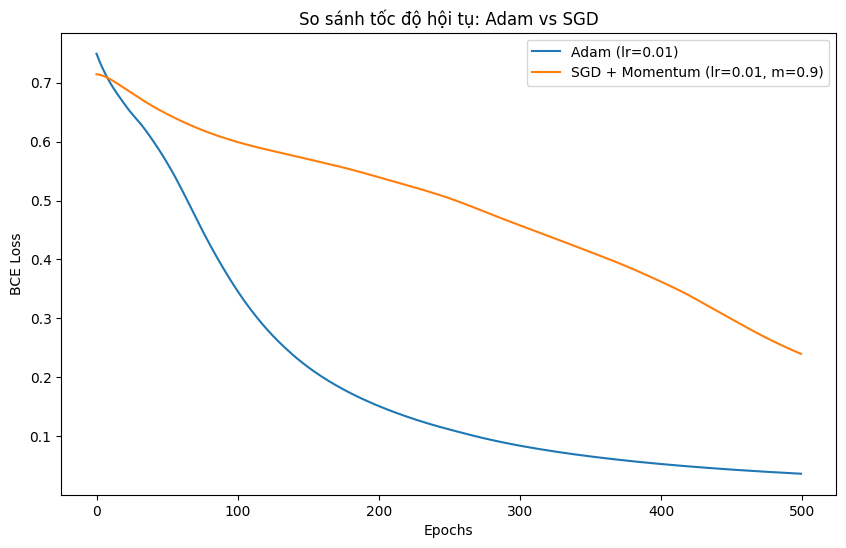

In [3]:
# 1. BCEWithLogitsLoss
class ANN_Logits(nn.Module):
    def __init__(self):
        super().__init__()
        # BỎ nn.Sigmoid ở cuối
        self.net = nn.Sequential(nn.Linear(2, 4), nn.ReLU(), nn.Linear(4, 1))
    def forward(self, x): return self.net(x)

model_logits = ANN_Logits()
criterion_logits = nn.BCEWithLogitsLoss() # Dùng hàm loss mới
optimizer_logits = optim.Adam(model_logits.parameters(), lr=0.01)

loss_logits_hist = []
for epoch in range(500):
    model_logits.train()
    optimizer_logits.zero_grad()
    out = model_logits(X_train)
    loss = criterion_logits(out, y_train)
    loss.backward()
    optimizer_logits.step()
    loss_logits_hist.append(loss.item())

model_logits.eval()
with torch.no_grad():
    # Phải áp dụng torch.sigmoid trước khi so sánh ngưỡng 0.5
    pred_logits = (torch.sigmoid(model_logits(X_test)) > 0.5).float()
    acc_logits = (pred_logits == y_test).float().mean().item()
print(f"BCEWithLogitsLoss - Test Acc: {acc_logits*100:.2f}%")

# 2. Đổi Adam thành SGD (cùng cấu trúc gốc)
model_sgd = ANN_4()
criterion_sgd = nn.BCELoss()
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)

loss_sgd_hist = []
for epoch in range(500):
    model_sgd.train()
    optimizer_sgd.zero_grad()
    loss = criterion_sgd(model_sgd(X_train), y_train)
    loss.backward()
    optimizer_sgd.step()
    loss_sgd_hist.append(loss.item())

# Vẽ so sánh hội tụ giữa Adam và SGD
plt.figure(figsize=(10, 6))
plt.plot(loss_4, label='Adam (lr=0.01)') # loss_4 lấy từ phần 1
plt.plot(loss_sgd_hist, label='SGD + Momentum (lr=0.01, m=0.9)')
plt.xlabel('Epochs')
plt.ylabel('BCE Loss')
plt.title('So sánh tốc độ hội tụ: Adam vs SGD')
plt.legend()
plt.show()

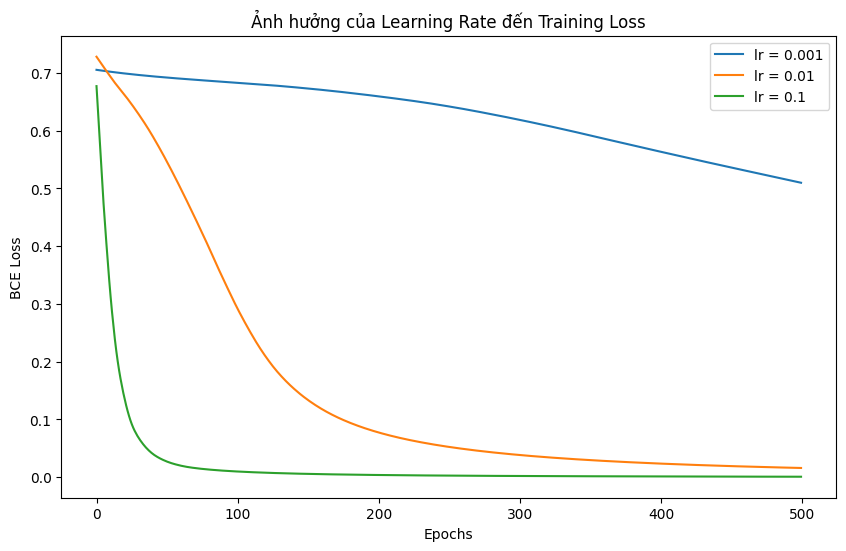

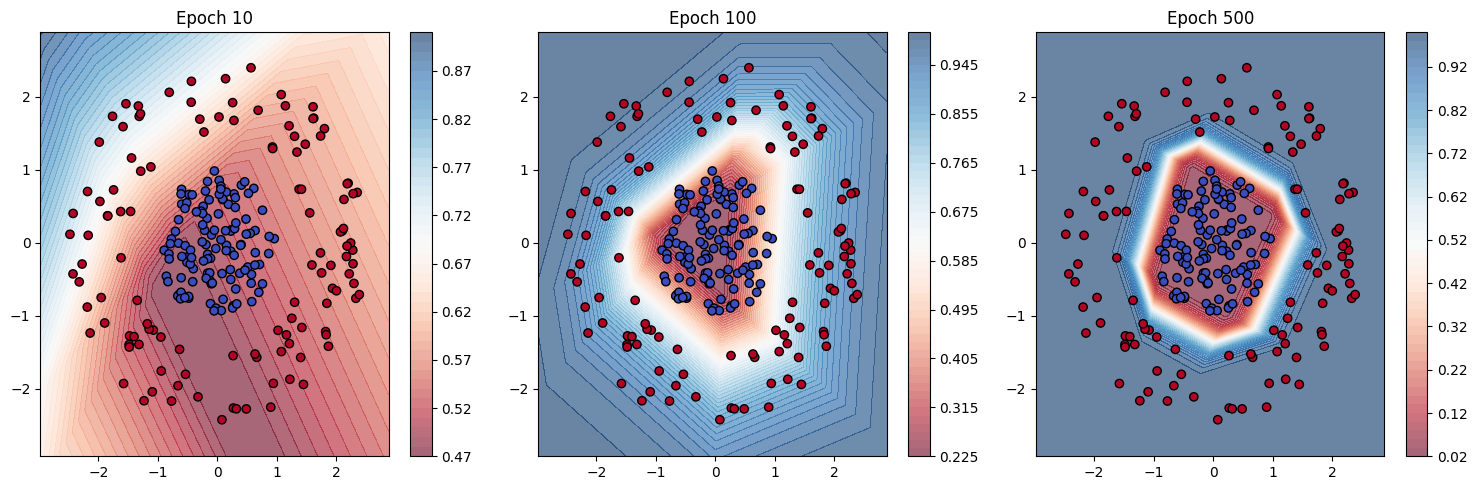

In [4]:
# 1. Thử 3 Learning Rates
lrs = [0.001, 0.01, 0.1]
loss_histories = {}

for lr in lrs:
    model = ANN_4()
    loss_h, _ = train_model(model, epochs=500, lr=lr)
    loss_histories[lr] = loss_h

plt.figure(figsize=(10, 6))
for lr, history in loss_histories.items():
    plt.plot(history, label=f'lr = {lr}')
plt.xlabel('Epochs')
plt.ylabel('BCE Loss')
plt.title('Ảnh hưởng của Learning Rate đến Training Loss')
plt.legend()
plt.show()

# 2. Vẽ ranh giới quyết định qua các epoch
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

    model.eval()
    with torch.no_grad():
        preds = model(grid).numpy().reshape(xx.shape)

    plt.contourf(xx, yy, preds, levels=50, cmap="RdBu", alpha=0.6)
    plt.colorbar()
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors='k')
    plt.title(title)

# Train 1 model và lưu state ở epoch 10, 100, 500
model_visual = ANN_4()
opt_visual = optim.Adam(model_visual.parameters(), lr=0.01)
crit_visual = nn.BCELoss()

epochs_to_plot = [10, 100, 500]
plt.figure(figsize=(15, 5))

for epoch in range(1, 501):
    model_visual.train()
    opt_visual.zero_grad()
    loss = crit_visual(model_visual(X_train), y_train)
    loss.backward()
    opt_visual.step()

    if epoch in epochs_to_plot:
        plt.subplot(1, 3, epochs_to_plot.index(epoch) + 1)
        plot_decision_boundary(model_visual, X_train_np, y_train_np, f'Epoch {epoch}')

plt.tight_layout()
plt.show()

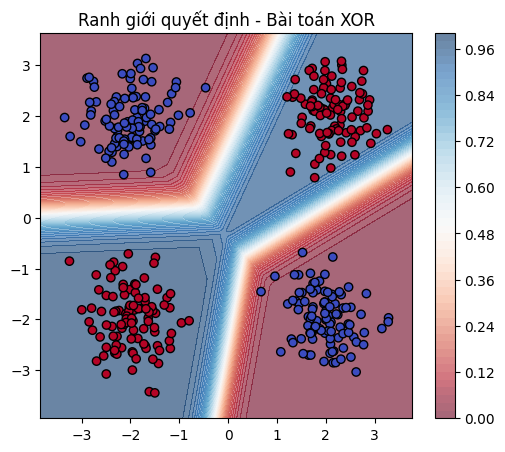

In [5]:
# 1. Sinh dữ liệu XOR
N_xor = 100
# Góc trên trái & dưới phải (Lớp 0)
X_0_1 = np.random.randn(N_xor, 2) * 0.5 + np.array([-2, 2])
X_0_2 = np.random.randn(N_xor, 2) * 0.5 + np.array([2, -2])
# Góc trên phải & dưới trái (Lớp 1)
X_1_1 = np.random.randn(N_xor, 2) * 0.5 + np.array([2, 2])
X_1_2 = np.random.randn(N_xor, 2) * 0.5 + np.array([-2, -2])

X_xor = np.vstack([X_0_1, X_0_2, X_1_1, X_1_2])
y_xor = np.array([0]*2*N_xor + [1]*2*N_xor)

X_xor_t = torch.FloatTensor(X_xor)
y_xor_t = torch.FloatTensor(y_xor).unsqueeze(1)

# 2. Huấn luyện ANN trên dữ liệu XOR
# Dùng cấu trúc 8 nút ẩn để dễ dàng học dạng XOR phức tạp
model_xor = ANN_8()
opt_xor = optim.Adam(model_xor.parameters(), lr=0.01)
crit_xor = nn.BCELoss()

for _ in range(500):
    opt_xor.zero_grad()
    loss = crit_xor(model_xor(X_xor_t), y_xor_t)
    loss.backward()
    opt_xor.step()

# 3. Vẽ ranh giới
plt.figure(figsize=(6, 5))
plot_decision_boundary(model_xor, X_xor, y_xor, 'Ranh giới quyết định - Bài toán XOR')
plt.show()